# 1. Introduction 

first, we load the packages and data

In [1]:
# Load packages (if not installed, then install)
if(!require(pacman)){ 
  install.packages("pacman")
  library(pacman)
}

p_load(MatchIt, optmatch, RItools, Hmisc, cobalt, tableone)

# Load lalonde data
data(lalonde)
# define two dummy variables to represent the race black and hispan and delete race variable
lalonde$black <- as.integer(as.character(lalonde$race) == "black") 
lalonde$hispan <- as.integer(as.character(lalonde$race) == "hispan") 
lalonde$race <- NULL
head(lalonde)

Loading required package: pacman

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘pacman’”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

also installing the dependencies ‘chk’, ‘RcppProgress’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done


MatchIt installed

also installing the dependency ‘rlemon’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done


optmatch installed

also installing the dependencies ‘abind’, ‘svd’, ‘SparseM’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done


RItools installed

also installing the dependencies ‘checkmate’, ‘cluster’, ‘foreign’, ‘gridExtra’, ‘htmlTable’, ‘viridis’, ‘Formula’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done


Hmisc installed

Updating HTML index of packages in '.Library'

Making 'packages.

,treat,age,educ,married,nodegree,re74,re75,re78,black,hispan
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,1,37,11,1,1,0,0,9930.0460,1,0
2,1,22,9,0,1,0,0,3595.8940,0,1
3,1,30,12,0,0,0,0,24909.4500,1,0
4,1,27,11,0,1,0,0,7506.1460,1,0
5,1,33,8,0,1,0,0,289.7899,1,0
6,1,22,9,0,1,0,0,4056.4940,1,0


Before we conducting PSM, let's simply compare the mean earning difference between two groups

In [2]:
# earning differen before matching 
tapply(lalonde$re78, lalonde$treat, mean)

0        1 
6984.170 6349.144

**??? why participation in training program lowers the future earning?**

# 2. Propensity Score Matching 

## 2.1 Near Neighbor Matching

**(1) PSM using near neighbor for a 1:1 ratio**

one participant in the control is matched to one participant in the treatment

In [3]:
# PSM using near-neighbor
m.nn <- matchit(treat ~ age + educ + nodegree + re74 + re75, 
                data = lalonde, 
                method = "nearest", 
                ratio = 1)
summary(m.nn)


Call:
matchit(formula = treat ~ age + educ + nodegree + re74 + re75, 
    data = lalonde, method = "nearest", ratio = 1)

Summary of Balance for All Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.2738          0.8059     0.7157    0.2009
age            25.8162       28.0303         -0.3094     0.4400    0.0813
educ           10.3459       10.2354          0.0550     0.4959    0.0347
nodegree        0.7081        0.5967          0.2450          .    0.1114
re74         2095.5737     5619.2365         -0.7211     0.5181    0.2248
re75         1532.0553     2466.4844         -0.2903     0.9563    0.1342
         eCDF Max
distance   0.3432
age        0.1577
educ       0.1114
nodegree   0.1114
re74       0.4470
re75       0.2876

Summary of Balance for Matched Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.3603          0.0413     1.0729    0.0116
age           

**(2) PSM using near neighbor for a 2:1 ratio**

there is also can be more than one participant from the control group to be matched with a participant in the treatment group. in this case, 2 individuals from control group is matched to a individual in the treatment group.
**Having more individuals from the control group matched to every individual in the treatment group means better estimates for the counterfactual in the control group. However, this approach requires a sample size for the control group several times larger than the number of individuals in the treatment group**

In [4]:
m.nn2 <- matchit(treat ~ age + educ + nodegree + re74 + re75, 
                 data = lalonde, 
                 method= "nearest", 
                 ratio = 2)
summary(m.nn2)


Call:
matchit(formula = treat ~ age + educ + nodegree + re74 + re75, 
    data = lalonde, method = "nearest", ratio = 2)

Summary of Balance for All Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.2738          0.8059     0.7157    0.2009
age            25.8162       28.0303         -0.3094     0.4400    0.0813
educ           10.3459       10.2354          0.0550     0.4959    0.0347
nodegree        0.7081        0.5967          0.2450          .    0.1114
re74         2095.5737     5619.2365         -0.7211     0.5181    0.2248
re75         1532.0553     2466.4844         -0.2903     0.9563    0.1342
         eCDF Max
distance   0.3432
age        0.1577
educ       0.1114
nodegree   0.1114
re74       0.4470
re75       0.2876

Summary of Balance for Matched Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.3058          0.5237     0.9694    0.1384
age           

## 2.2 Near Neighbor with Caliper Matching

in near neighbor matching, sometimes individuals who are not close in terms of their propensity scores, can be matched. Thus, in this case, near neighbor-match can be considered only if the absolute distance between treatment and control participants meets the condition(caliper)

In [5]:
#  PSM using near neighbor with a caliper of 0.1 

In [6]:
m.nnc <- matchit(treat ~ age + educ + nodegree + re74 + re75, 
                 data = lalonde, 
                 method= "nearest", 
                 caliper = .1)
summary(m.nnc)


Call:
matchit(formula = treat ~ age + educ + nodegree + re74 + re75, 
    data = lalonde, method = "nearest", caliper = 0.1)

Summary of Balance for All Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.2738          0.8059     0.7157    0.2009
age            25.8162       28.0303         -0.3094     0.4400    0.0813
educ           10.3459       10.2354          0.0550     0.4959    0.0347
nodegree        0.7081        0.5967          0.2450          .    0.1114
re74         2095.5737     5619.2365         -0.7211     0.5181    0.2248
re75         1532.0553     2466.4844         -0.2903     0.9563    0.1342
         eCDF Max
distance   0.3432
age        0.1577
educ       0.1114
nodegree   0.1114
re74       0.4470
re75       0.2876

Summary of Balance for Matched Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3560        0.3548          0.0111     1.0228    0.0047
age       

## 2.3 Optimal Matching

find the matched samples with the smallest average absolute propensity score distance across all the matched pairs

In [7]:
# Optimal matching with 1:1 ratio
m.om <- matchit(treat ~ age + educ + nodegree + re74 + re75, 
                data = lalonde, 
                method= "optimal", 
                ratio = 1)
summary(m.om)


Call:
matchit(formula = treat ~ age + educ + nodegree + re74 + re75, 
    data = lalonde, method = "optimal", ratio = 1)

Summary of Balance for All Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.2738          0.8059     0.7157    0.2009
age            25.8162       28.0303         -0.3094     0.4400    0.0813
educ           10.3459       10.2354          0.0550     0.4959    0.0347
nodegree        0.7081        0.5967          0.2450          .    0.1114
re74         2095.5737     5619.2365         -0.7211     0.5181    0.2248
re75         1532.0553     2466.4844         -0.2903     0.9563    0.1342
         eCDF Max
distance   0.3432
age        0.1577
educ       0.1114
nodegree   0.1114
re74       0.4470
re75       0.2876

Summary of Balance for Matched Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.3626          0.0215     1.0366    0.0087
age           

## 2.3 Full Matching 

Full matching is a form of optimal matching where participants in either the control or treatment groups will be matched to one or more individuals in the opposite group. This matching is accomplished by creating subclasses automatically, and then assigning at least one individual from either the control or treatment group, and as many individuals of the opposite group. Similarly to optimal matching this approach is intended to minimize the average of the distances between treatment and control individuals within each set. This approach is ideal for researchers who would rather not discard any participant in either sample.

In [8]:
# Full matching, a minimum number and a maximum number of control cases are specified.
m.fl <- matchit(treat ~ age + educ + nodegree + re74 + re75, 
                data = lalonde, 
                method= "full", 
                min.controls = 1, 
                max.controls = 10, 
                discard = "both")
summary(m.fl)


Call:
matchit(formula = treat ~ age + educ + nodegree + re74 + re75, 
    data = lalonde, method = "full", discard = "both", min.controls = 1, 
    max.controls = 10)

Summary of Balance for All Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.2738          0.8059     0.7157    0.2009
age            25.8162       28.0303         -0.3094     0.4400    0.0813
educ           10.3459       10.2354          0.0550     0.4959    0.0347
nodegree        0.7081        0.5967          0.2450          .    0.1114
re74         2095.5737     5619.2365         -0.7211     0.5181    0.2248
re75         1532.0553     2466.4844         -0.2903     0.9563    0.1342
         eCDF Max
distance   0.3432
age        0.1577
educ       0.1114
nodegree   0.1114
re74       0.4470
re75       0.2876

Summary of Balance for Matched Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3669        0.3630      

# 3. Conducting a Propensity Score Analysis

## 3.1 Preliminary Analysis

**Before propensity scores are calculated, it is a good practice to determine if the two groups are balanced.** The best practice to determine the covariates that influence group assignment is based on theoretical evidence. In addition, statistical tests can also be used to determine if the covariates are imbalanced across groups. Traditional statistical approaches include the:

**(1) Welch Two Sample t-test**

In [9]:
# 1. Difference-in-means: Outcome variable (re78)
with(lalonde, t.test(re78 ~ treat))


	Welch Two Sample t-test

data:  re78 by treat
t = 0.93773, df = 326.41, p-value = 0.3491
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -697.192 1967.244
sample estimates:
mean in group 0 mean in group 1 
       6984.170        6349.144 


In [10]:
#2. Difference-in-means: pre-treatment covariates
datcov <- c('age', 'educ', 'nodegree', 'married', 'black', 'hispan', 're74', 're75')

lapply(datcov, function(v) {
  t.test(lalonde[[v]] ~ lalonde[['treat']])
})

[[1]]

	Welch Two Sample t-test

data:  lalonde[[v]] by lalonde[["treat"]]
t = 2.9911, df = 510.57, p-value = 0.002914
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 0.7598127 3.6683610
sample estimates:
mean in group 0 mean in group 1 
       28.03030        25.81622 


[[2]]

	Welch Two Sample t-test

data:  lalonde[[v]] by lalonde[["treat"]]
t = -0.54676, df = 485.37, p-value = 0.5848
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.5076687  0.2866393
sample estimates:
mean in group 0 mean in group 1 
       10.23543        10.34595 


[[3]]

	Welch Two Sample t-test

data:  lalonde[[v]] by lalonde[["treat"]]
t = -2.7127, df = 374.01, p-value = 0.006982
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.19210040 -0.03064263
sample estimates:
me

**(2) Chi-square Test** 

it checks if there is at least one variable in the model for which the two groups are different. 

In [11]:
# XBalance function from the RItools packages
xBalance(treat ~ age + educ + nodegree + re74 + re75, 
         data = lalonde, 
         report = c("chisquare.test"))

,chisquare,df,p.value
,<dbl>,<dbl>,<dbl>
unstrat,50.32412,5,1.189498e-09


**(3) Outcome model**

as part of the preliminary analysis it is a good practice to assess the effects of the treatment on the outcome variable by running the outcome model. This assessment can be based on the treatment variable only (using a t-test), or include covariates (using a regression model)

In [12]:
# Outcome model using Regression analysis
reg <- lm(re78 ~ treat + age + educ + nodegree + re74 + re75 + married + black + hispan, 
          data = lalonde)
summary(reg)


Call:
lm(formula = re78 ~ treat + age + educ + nodegree + re74 + re75 + 
    married + black + hispan, data = lalonde)

Residuals:
   Min     1Q Median     3Q    Max 
-13595  -4894  -1662   3929  54570 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  6.651e+01  2.437e+03   0.027   0.9782    
treat        1.548e+03  7.813e+02   1.982   0.0480 *  
age          1.298e+01  3.249e+01   0.399   0.6897    
educ         4.039e+02  1.589e+02   2.542   0.0113 *  
nodegree     2.598e+02  8.474e+02   0.307   0.7593    
re74         2.964e-01  5.827e-02   5.086 4.89e-07 ***
re75         2.315e-01  1.046e-01   2.213   0.0273 *  
married      4.066e+02  6.955e+02   0.585   0.5590    
black       -1.241e+03  7.688e+02  -1.614   0.1071    
hispan       4.989e+02  9.419e+02   0.530   0.5966    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6948 on 604 degrees of freedom
Multiple R-squared:  0.1478,	Adjusted R-squared:  0.

## 3.2 Estimation of the Propensity Scores

In [13]:
# Calculates the propensity score
ps <- glm(treat ~ age + educ + nodegree + re74 + re75, 
          data = lalonde, 
          family = binomial())
summary(ps)


Call:
glm(formula = treat ~ age + educ + nodegree + re74 + re75, family = binomial(), 
    data = lalonde)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.694e+00  7.989e-01  -3.372 0.000746 ***
age          2.464e-03  1.025e-02   0.240 0.810019    
educ         1.569e-01  5.299e-02   2.962 0.003059 ** 
nodegree     8.502e-01  2.813e-01   3.023 0.002503 ** 
re74        -1.225e-04  2.576e-05  -4.756 1.98e-06 ***
re75         2.574e-05  3.955e-05   0.651 0.515252    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 751.49  on 613  degrees of freedom
Residual deviance: 692.88  on 608  degrees of freedom
AIC: 704.88

Number of Fisher Scoring iterations: 5


**it is suggested that the final model should include not only statistically significant variables, but also variables known to be associated with selection.**

Once the propensity scores have been calculated, a graphical approach can be used to assess the distributional similarity between score distributions. we can use function from the *Hmisc* package to generate Back to back histogram

,treat,age,educ,married,nodegree,re74,re75,re78,black,hispan,psvalue
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
1,1,37,11,1,1,0,0,9930.0460,1,0,0.4934196
2,1,22,9,0,1,0,0,3595.8940,0,1,0.4068168
3,1,30,12,0,0,0,0,24909.4500,1,0,0.3236947
4,1,27,11,0,1,0,0,7506.1460,1,0,0.4872631
5,1,33,8,0,1,0,0,289.7899,1,0,0.3759033
6,1,22,9,0,1,0,0,4056.4940,1,0,0.4068168


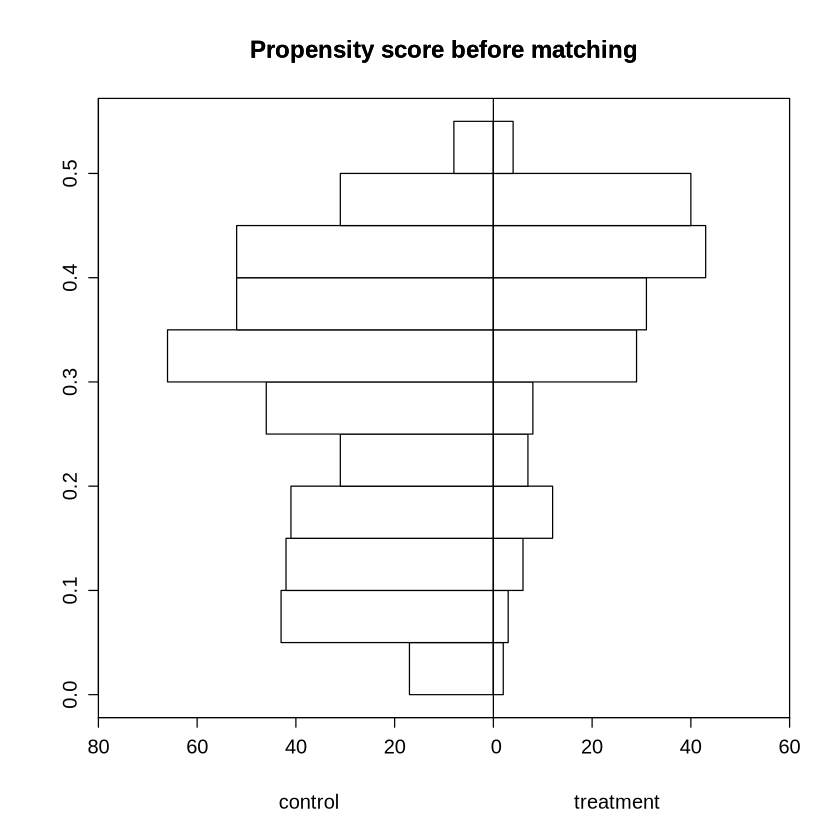

In [14]:
# Attach the predicted propensity score to the dataframe
lalonde$psvalue <- predict(ps, type = "response")
head(lalonde)
# Back to back histogram using Hmisc
histbackback(split(lalonde$psvalue, lalonde$treat), main= "Propensity score before matching", xlab=c("control", "treatment"))

## 3.3 Propensity Score Matching (PSM) and Balance Check

As discussed earlier, there are many methods for estimating PS, here let's say if the match ratio was 1:1, and there were 429 individuals in the control group and 185 in the treatment group, then 244 individuals from the control group will not be matched.

In [15]:
# Match using near-neighbor
m.nn <- matchit(treat ~ age + educ + nodegree + re74 + re75, 
                data = lalonde,
                method = "nearest", 
                ratio = 1)
# use summary to check the matching quality
summary(m.nn)


Call:
matchit(formula = treat ~ age + educ + nodegree + re74 + re75, 
    data = lalonde, method = "nearest", ratio = 1)

Summary of Balance for All Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.2738          0.8059     0.7157    0.2009
age            25.8162       28.0303         -0.3094     0.4400    0.0813
educ           10.3459       10.2354          0.0550     0.4959    0.0347
nodegree        0.7081        0.5967          0.2450          .    0.1114
re74         2095.5737     5619.2365         -0.7211     0.5181    0.2248
re75         1532.0553     2466.4844         -0.2903     0.9563    0.1342
         eCDF Max
distance   0.3432
age        0.1577
educ       0.1114
nodegree   0.1114
re74       0.4470
re75       0.2876

Summary of Balance for Matched Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.3650        0.3603          0.0413     1.0729    0.0116
age           

**Export matched data**

In [16]:
mdata <- match.data(m.nn)
head(mdata)

,treat,age,educ,married,nodegree,re74,re75,re78,black,hispan,psvalue,distance,weights,subclass
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>
1,1,37,11,1,1,0,0,9930.0460,1,0,0.4934196,0.4934196,1,1
2,1,22,9,0,1,0,0,3595.8940,0,1,0.4068168,0.4068168,1,98
3,1,30,12,0,0,0,0,24909.4500,1,0,0.3236947,0.3236947,1,109
4,1,27,11,0,1,0,0,7506.1460,1,0,0.4872631,0.4872631,1,120
5,1,33,8,0,1,0,0,289.7899,1,0,0.3759033,0.3759033,1,131
6,1,22,9,0,1,0,0,4056.4940,1,0,0.4068168,0.4068168,1,142


In this section, we investigate how to check balance in covariate distributions between treatment and control groups. we introduce three methods:

**1. Check the standardized mean differences (SMD) and variance ratios (VR)**

It is recommended that a covariate is balanced only when the absolute SMD value is **<0.25**, or more stricter, **<0.1**.
The VR is the ratio of variance in the treatment and control groups. A VR close to **1.0** indicates a balance in the covariate, whereas a **VR <0.5 or >2.0** are considered “too extreme”

(1) SMD: The function *bal.tab* in cobalt package provides a useful way to calculate SMD. Here, the argument *m.threshold* is a numeric value for the SMD threshold. This function shows which covariates are balanced (SMDs are under the threshold), which covariates are unbalanced, which covariate has the greatest mean difference, and the sample size of the matched data.

In [17]:
bal.tab(m.nn, m.threshold = 0.1, un = TRUE)

Balance Measures
             Type Diff.Un Diff.Adj        M.Threshold
distance Distance  0.8059   0.0413     Balanced, <0.1
age       Contin. -0.3094   0.1443 Not Balanced, >0.1
educ      Contin.  0.0550   0.0887     Balanced, <0.1
nodegree   Binary  0.1114  -0.0378     Balanced, <0.1
re74      Contin. -0.7211  -0.0252     Balanced, <0.1
re75      Contin. -0.2903   0.0320     Balanced, <0.1

Balance tally for mean differences
                   count
Balanced, <0.1         5
Not Balanced, >0.1     1

Variable with the greatest mean difference
 Variable Diff.Adj        M.Threshold
      age   0.1443 Not Balanced, >0.1

Sample sizes
          Control Treated
All           429     185
Matched       185     185
Unmatched     244       0

in this table, we can see the age is still not balanced, because our threshold for SMD is too strict

(2) VR: The VR can be calculated and checked by setting the argument *v.threshold*, which is a numeric value for the VR threshold. a good VR is 0.5–2. In this function however, if VR is < 1, it will be converted to the inverse (1/VR). Therefore, we just need to set *v.threshold* = 2.

In [18]:
bal.tab(m.nn, v.threshold = 2)

Balance Measures
             Type Diff.Adj V.Ratio.Adj  V.Threshold
distance Distance   0.0413      1.0729 Balanced, <2
age       Contin.   0.1443      0.5500 Balanced, <2
educ      Contin.   0.0887      0.5905 Balanced, <2
nodegree   Binary  -0.0378           .             
re74      Contin.  -0.0252      1.2495 Balanced, <2
re75      Contin.   0.0320      1.9641 Balanced, <2

Balance tally for variance ratios
                 count
Balanced, <2         5
Not Balanced, >2     0

Variable with the greatest variance ratio
 Variable V.Ratio.Adj  V.Threshold
     re75      1.9641 Balanced, <2

Sample sizes
          Control Treated
All           429     185
Matched       185     185
Unmatched     244       0

**2. Graphical Method: Distribution Visualization**

**(1) Q–Q plot(default)**

The Q–Q plots demonstrate deviations between empirical distributions of treated and control groups. The points in Q–Q plots lie on the y = x line. Larger deviations indicate greater differences between the distributions.

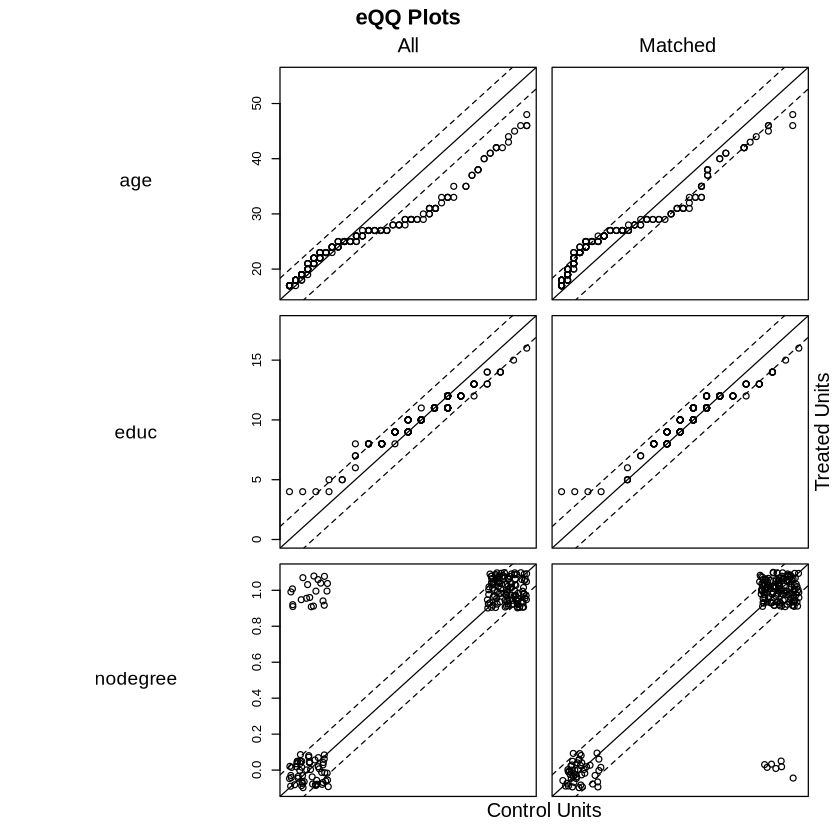

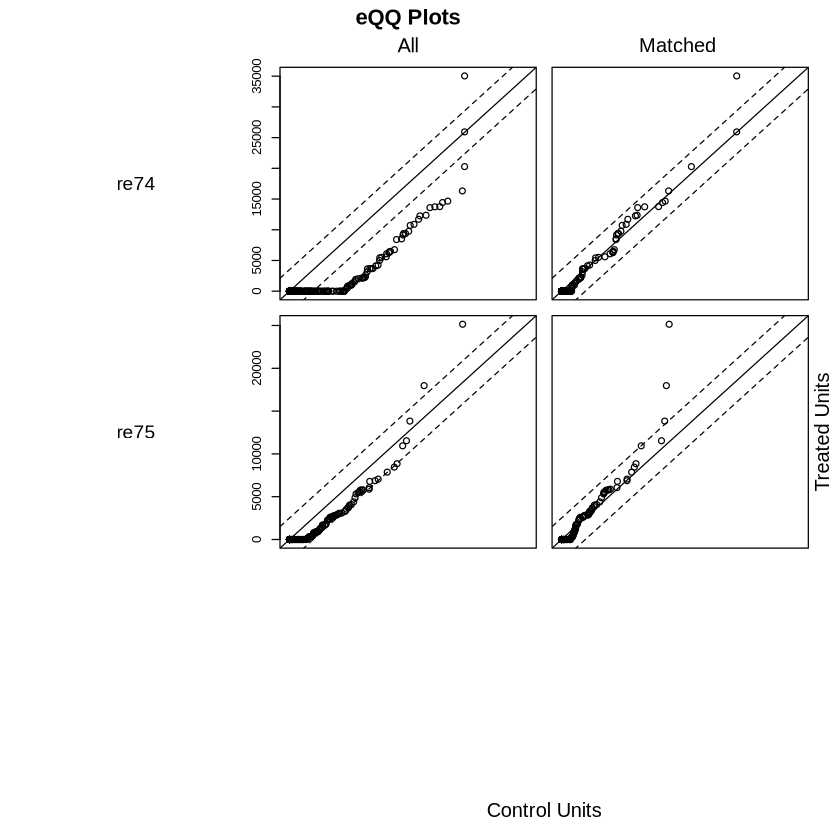

In [19]:
plot(m.nn)

**(2) jitter plot**

Jitter plots show the PS distributions of unmatched treatment units, matched treatment units, matched control units, and unmatched control units. Every circle in the jitter plot represents a patient, and its size is proportional to its weight given by the matchit function.

To identify the units, use first mouse button; to stop, use second.


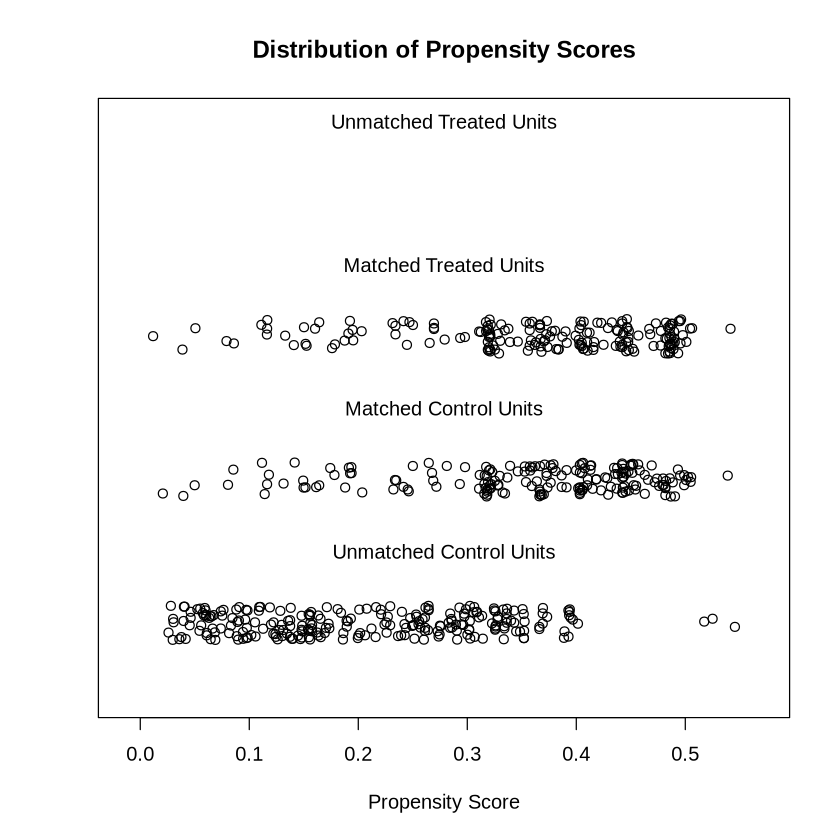

In [20]:
plot(m.nn, type = 'jitter')

**(3) histogram**

it shows the distributional density of PS before and after matching

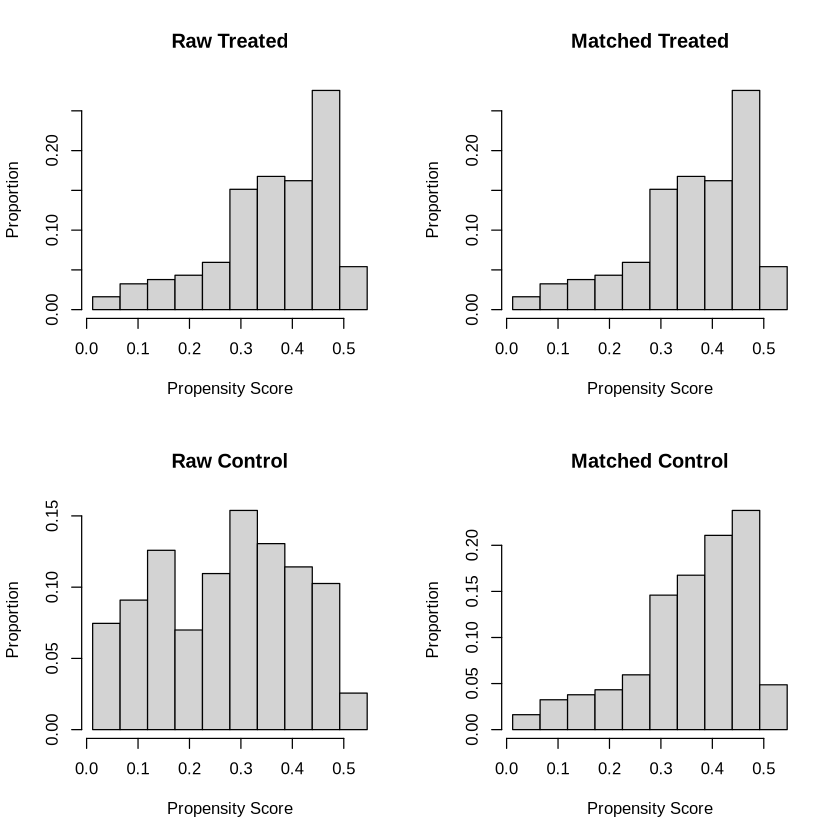

In [21]:
plot(m.nn, type = 'hist')

**(4) *bar.plot* function in *cobalt* package**

(4.1) The density plot to display for continuous variables, like age, re74, re75

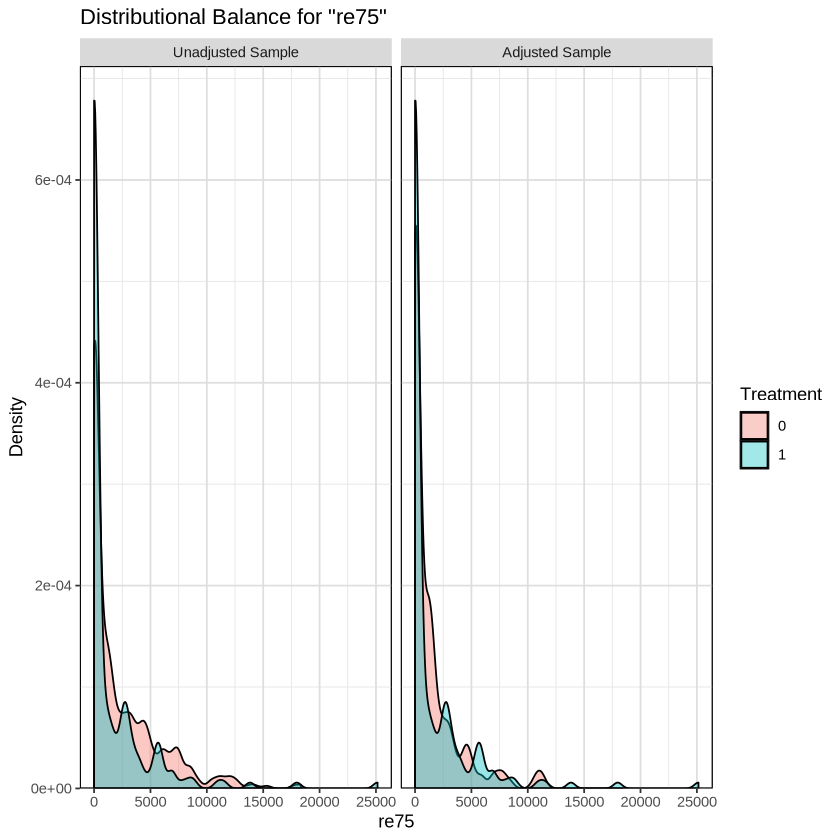

In [22]:
bal.plot(m.nn, var.name = 're75', which = 'both', grid=TRUE)

(4.2) Empirical cumulative density function plots for continous variable

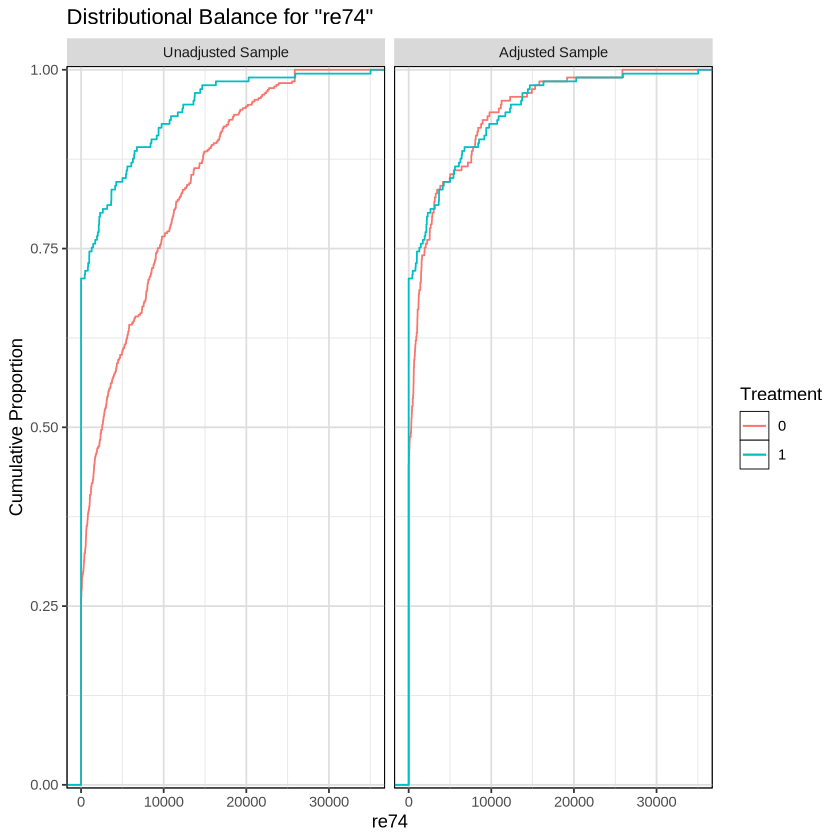

In [23]:
bal.plot(m.nn, var.name = 're74', which = 'both', grid=TRUE, type="ecdf")

(4.3) distribution histogram to display for categorical variables, like nodegree

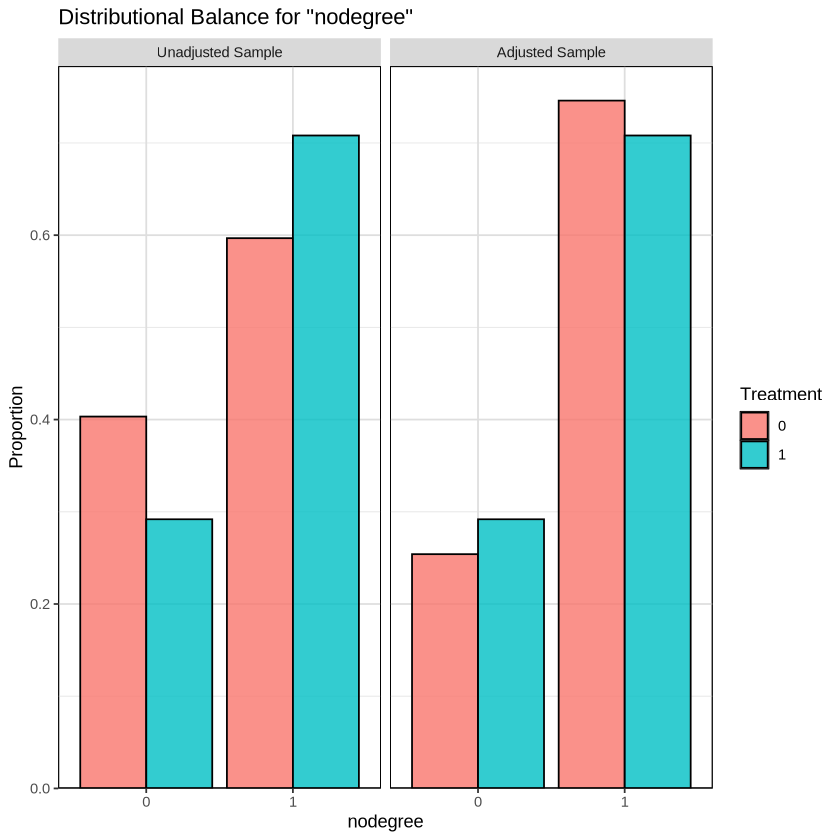

In [24]:
bal.plot(m.nn, var.name = 'nodegree', which = 'both', grid=TRUE)

(4.4) Love plots: compare SMDs of covariates before and after matching, where two vertical dotted lines are drawn as the 0.1 threshold of SMD, and every point represents the SMD of a covariate before or after PSM adjustment. If a point lies between two lines, then the corresponding covariate has been balanced.

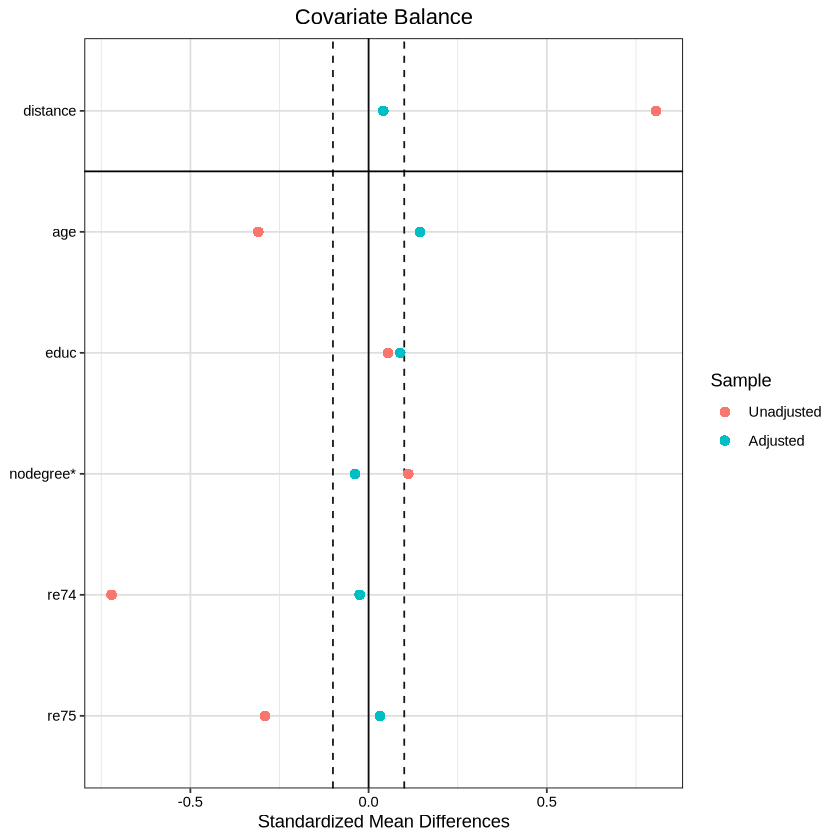

In [25]:
love.plot(bal.tab(m.nn, m.threshold = 0.1),
          stat = "mean.diffs",
          grid = TRUE,
          stars = "raw",
          abs = F)

**(4) back to back histogram after the match**

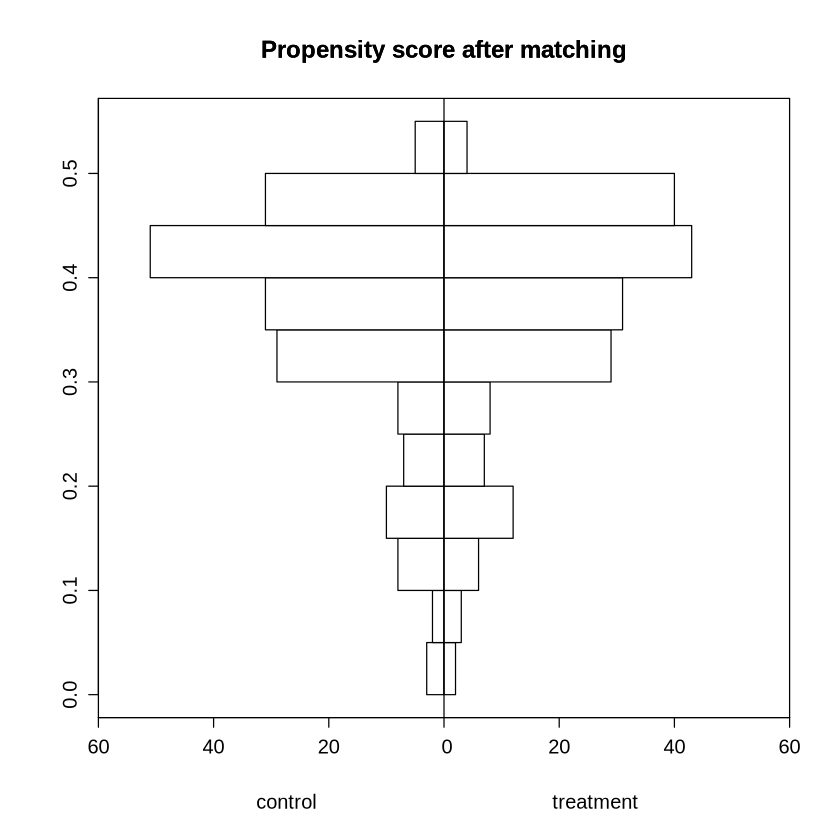

In [26]:
histbackback(split(mdata$psvalue, mdata$treat), main= "Propensity score after matching", xlab=c("control", "treatment"))

**3. Statitical Test:**

**(1) Welch two sample t test**

In [27]:
lapply(datcov, function(v) {
       t.test(mdata[[v]] ~ mdata[['treat']])
       })

[[1]]

	Welch Two Sample t-test

data:  mdata[[v]] by mdata[["treat"]]
t = -1.1691, df = 339.39, p-value = 0.2432
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -2.7694866  0.7046218
sample estimates:
mean in group 0 mean in group 1 
       24.78378        25.81622 


[[2]]

	Welch Two Sample t-test

data:  mdata[[v]] by mdata[["treat"]]
t = -0.73523, df = 345.12, p-value = 0.4627
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.6555686  0.2988119
sample estimates:
mean in group 0 mean in group 1 
       10.16757        10.34595 


[[3]]

	Welch Two Sample t-test

data:  mdata[[v]] by mdata[["treat"]]
t = 0.81541, df = 367.31, p-value = 0.4154
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.0534117  0.1290874
sample estimates:
mean in group 0 m

**(2) Chi-square test**

In [28]:
# chi-square test
xBalance(treat ~ age + educ + nodegree + re74 + re75, data = mdata, report = c("chisquare.test"))

,chisquare,df,p.value
,<dbl>,<dbl>,<dbl>
unstrat,2.640361,5,0.7552238


As can be observed in this figure, although the chi-square test indicates no significance, thus suggesting equivalence between the groups, the standardized difference test shows that there are some variables with a large difference (i.e., black, hispan, married) that can still be improved. Potential suggestions might include the use of interactions terms, or polynomial terms to try to reduce their imbalance.

## 3.4 Estimating treatment Effect

In [29]:
# before matching
tapply(lalonde$re78, lalonde$treat, mean)
# after matching
tapply(mdata$re78, mdata$treat, mean)

0        1 
6984.170 6349.144

0        1 
6008.987 6349.144

Mystery solved !

**However, is the treatment effect significant?**

In [30]:
with(mdata, t.test(re78 ~ treat))


	Welch Two Sample t-test

data:  re78 by treat
t = -0.45711, df = 352.69, p-value = 0.6479
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -1803.679  1123.366
sample estimates:
mean in group 0 mean in group 1 
       6008.987        6349.144 


**The result is not significant even at a 0.1 significance level.** However, this does not imply that the treatment has no effect; it means that, for now, we don't have enough evidence to support that claim. It could yield significant results with a larger dataset。

now we can also estimate the treatment effect using regression without covariates, why?

In [31]:
lmtreat <- lm(re78 ~ treat, data = mdata)
summary(lmtreat)


Call:
lm(formula = re78 ~ treat, data = mdata)

Residuals:
   Min     1Q Median     3Q    Max 
 -6349  -5797  -1961   3187  53959 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6009.0      526.2  11.420   <2e-16 ***
treat          340.2      744.1   0.457    0.648    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7157 on 368 degrees of freedom
Multiple R-squared:  0.0005675,	Adjusted R-squared:  -0.002148 
F-statistic: 0.2089 on 1 and 368 DF,  p-value: 0.6479


**The regression coefficient equals the mean outcome difference after matching, and they both equal the treatment effect.**
So, next time when you try to run some regressions on the two variables that you found interesting using the **observational data**, be extremely careful; this could be really dangerous.

# 4. The differences and similarities between PSM and regression

**Recall what you learned in the last tutorial. What do Regression and PSM have in common?**

# 5. Exercise 

## 5.1 preparation 

**Copy and run the following code in R Studio to obtain a simulated medical dataset. The exercises are based on this data.**

In [32]:
## data generation
set.seed(2024)
# 400 females and 600 males
x.Gender <- rep(0:1, c(400,600)) 
x.Age <- round(abs(rnorm(1000, mean=45, sd=15)))
z <- (x.Age - 45) / 15 - (x.Age-45) ^ 2 / 100 + 2 * x.Gender
# The true PS
tps <- exp(z) / (1+exp(z)) 
Smoke <- as.numeric(runif(1000) < tps)
z.y <- x.Gender + 0.3*x.Age + 5*Smoke - 20
y <- exp(z.y) / (1+exp(z.y))
CVD <- as.numeric(runif(1000) < y)
# Form a dataframe
dat <- data.frame(x.Age, x.Gender, Smoke, CVD)
head(dat)

,x.Age,x.Gender,Smoke,CVD
,<dbl>,<int>,<dbl>,<dbl>
1,60,0,0,0
2,52,0,0,0
3,43,0,1,0
4,42,0,0,0
5,62,0,0,0
6,64,0,0,0


in this dataset, We want to study the relationship between smoking and CVD (cardiovascular disease) incidence.
so in this case, the CVD is the outcome variable (CVD = 0 when the patient does not have CVD; otherwise, CVD =1) and Smoking is a binary variable which indicates whether the patient smokes or not. Gender (0= female, 1= male) and age are two confounding covariates, which are correlated to “treatment” and outcome.

## 5.2 Following the above instructions and conducting the PSM (4 steps).

**Hint: 
(1) In the preliminary analysis, run the Welch two sample t test for the outcome variable and covariates. 
(2) Estimating the PS. 
(3) Conducting the PSM using near-neighbor with ratio = 1 and examining covariate balance in the matched sample(choose one method you like). 
(4) Estimating treatment effect**